# *Import Libraries*

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# *Loading the Dataset*

In [53]:
df = pd.read_csv('/content/healthcare_dataset.csv')

In [54]:
df['Medical Condition'].unique()

array(['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension',
       'Cancer'], dtype=object)

# *EDA*

In [55]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [56]:
df.describe()


,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


In [57]:
df.dtypes

,0
Name,object
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,object
Doctor,object
Hospital,object
Insurance Provider,object
Billing Amount,float64


In [58]:
df.isna().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [60]:
df.nunique()

,0
Name,9378
Age,68
Gender,2
Blood Type,8
Medical Condition,6
Date of Admission,1815
Doctor,9416
Hospital,8639
Insurance Provider,5
Billing Amount,10000


In [61]:
df = df.drop(columns=['Doctor', 'Hospital', 'Billing Amount', 'Room Number', 'Name', 'Discharge Date', 'Date of Admission' ])

# *Visualization*

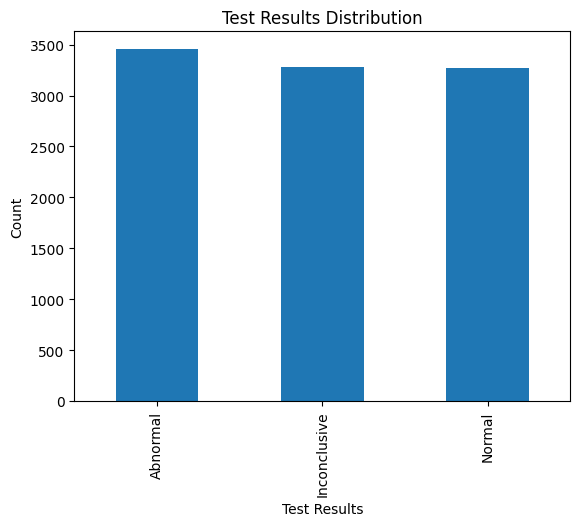

In [62]:
df['Test Results'].value_counts().plot(kind='bar')
plt.title("Test Results Distribution")
plt.xlabel("Test Results")
plt.ylabel("Count")
plt.show()

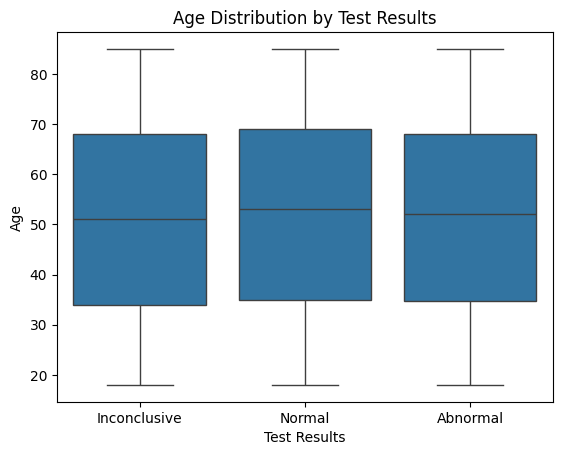

In [63]:
sns.boxplot(x='Test Results', y='Age', data=df)
plt.title("Age Distribution by Test Results")
plt.show()

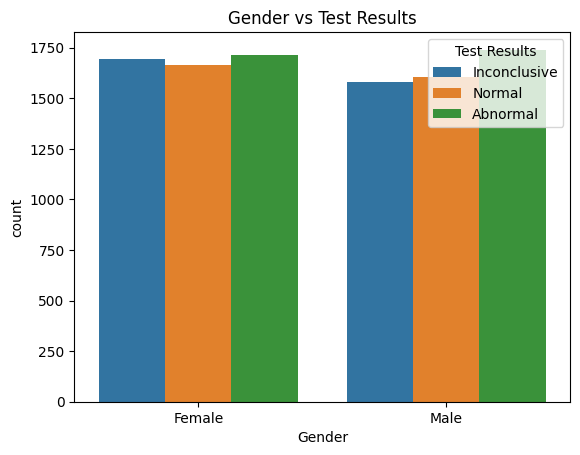

In [64]:
sns.countplot(x='Gender', hue='Test Results', data=df)
plt.title("Gender vs Test Results")
plt.show()

# *Encoding*

In [65]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = ['Gender', 'Insurance Provider', 'Admission Type', 'Medication', 'Medical Condition', 'Blood Type']
le = LabelEncoder()
for i in categorical_cols:
    df[i] = le.fit_transform(df[i])

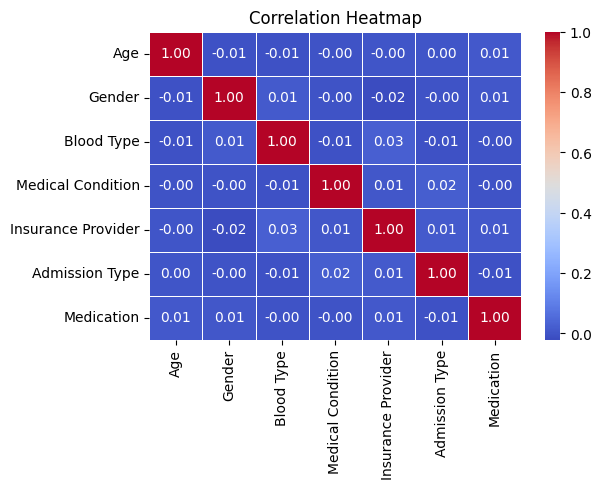

In [66]:
plt.figure(figsize=(6,4))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# *Split Data*

In [67]:
x = df.drop('Test Results', axis=1)
y = df['Test Results']

In [68]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# *Modeling Logistic Regression*

In [69]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2500)
model.fit(x_train, y_train)

LogisticRegression(max_iter=2500)

#*Evaluation Logistic Regression*

In [70]:
y_pred = model.predict(x_test)

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[440 196  70]
 [393 180  63]
 [396 181  81]]


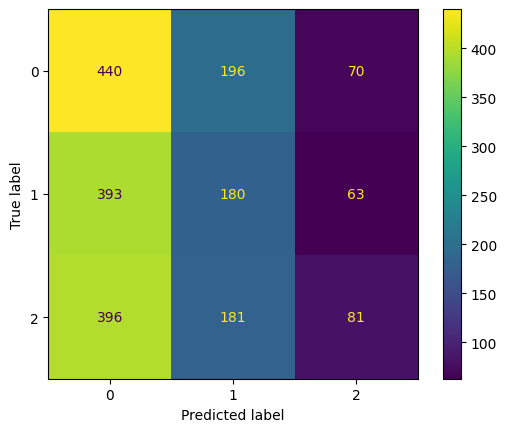

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [73]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Abnormal       0.36      0.62      0.45       706
Inconclusive       0.32      0.28      0.30       636
      Normal       0.38      0.12      0.19       658

    accuracy                           0.35      2000
   macro avg       0.35      0.34      0.31      2000
weighted avg       0.35      0.35      0.32      2000

